In [212]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from lokan import *
from lokan import loKAN
from lokan.utils import ex_round

In [213]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# **Dataset** $y = x_0 x_1$

In [225]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
y = x[:, 0] * x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

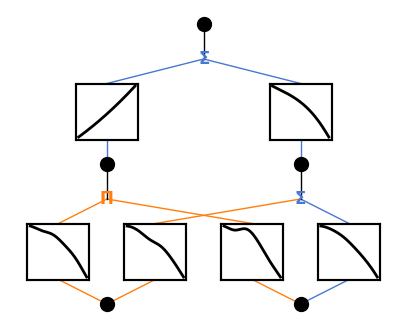

In [226]:
model = loKAN(width=[2, 2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [227]:
history = model.fit(dataset=dataset,
                    lr_start=0.1, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    # update_grid=True,
                    update_grid=False, 
                    # grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    refine_schedule=[(20, 5)],
                    verbose=10)

Epoch [  10/120]  train=0.000498  test=0.000290  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.000218  test=0.000139  tau=1.240  λ=0.0209  grid=5
  [refine] epoch 20: grid → 5
Epoch [  30/120]  train=0.000086  test=0.000069  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.000039  test=0.000035  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.000016  test=0.000009  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.000036  test=0.000010  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.000010  test=0.000007  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.000008  test=0.000005  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.000006  test=0.000005  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.000007  test=0.000005  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.000005  test=0.000004  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.000005  test=0.000004  tau=0.100  λ=1.0000  grid=5


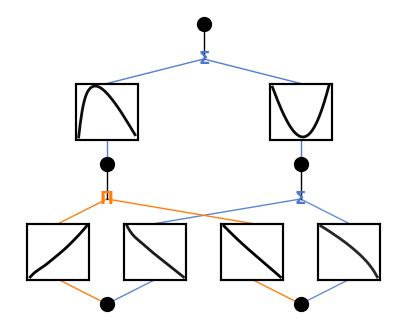

In [211]:
model.plot()

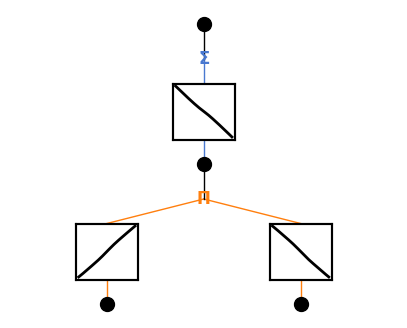

In [144]:
model_pruned = model.prune()
model_pruned.plot()

In [87]:
# model.suggest_symbolic(0, 1, 0)

In [8]:
model.auto_symbolic()

fixing (0,0,0) with x, r2=1.0000, c=1
fixing (0,1,0) with x, r2=1.0000, c=1


In [9]:
exprs, syms = model.symbolic_formula(tau_decode=0.05, simplify=True)

In [10]:
print(exprs[0])

1.0*(1.00025142664727*x_1 - 0.000145272161859111)*(0.995634483784755*x_2 - 2.36857937032653e-5)


In [11]:
expr_rounded = ex_round(exprs[0], 2)

In [12]:
print(expr_rounded)

1.0*x_1*x_2


In [13]:
expr_rounded = ex_round(expr_rounded, 2)
expr_rounded

1.0*x_1*x_2

In [54]:
syms

[x_1, x_2]

In [96]:
print("Output expression:", exprs[0])
print("Node (0,0):", model.get_sym_node(0, 0))  # input 0
print("Node (0,1):", model.get_sym_node(0, 1))  # input 1
print("Node (1,0):", model.get_sym_node(1, 0))  # output
print("Edge(0,0,0):", model.get_sym_edge(0, 0, 0))  # layer 0, i=0, j=0
print("Edge(0,1,0):", model.get_sym_edge(0, 1, 0))  # layer 0, i=1, j=0
print("sym_expr_edges length:", len(model.sym_expr_edges))
print("sym_expr_nodes length:", len(model.sym_expr_nodes))

Output expression: 1.0*(1.08977719588867*x_1 + 0.000137209377044201)*(0.912377828089291*x_2 + 0.000104250849858545)
Node (0,0): x_1
Node (0,1): x_2
Node (1,0): 1.0*(1.08977719588867*x_1 + 0.000137209377044201)*(0.912377828089291*x_2 + 0.000104250849858545)
Edge(0,0,0): 1.08977719588867*x_1 + 0.000137209377044201
Edge(0,1,0): 0.912377828089291*x_2 + 0.000104250849858545
sym_expr_edges length: 1
sym_expr_nodes length: 2


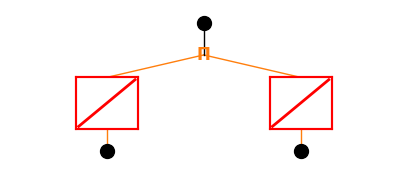

In [103]:
model.plot()

# **Dataset** $y = x_0 x_1$